In [ ]:
import pandas as pd

df = pd.read_csv('Reddit_Data.csv')
df.head(10)

,title,type,year,post,post_clean
0,Better Call Saul,linear,2017,Walter. And there the chain ends.,Walter. And there the chain ends.
1,Better Call Saul,linear,2016,I love this show. But it's hard to argue again...,I love this show. But it's hard to argue again...
2,Better Call Saul,linear,2017,What am I missing? A lot of reference to ribs...,What am I missing? A lot of reference to ribs ...
3,Better Call Saul,linear,2018,"Oh come on Mike, he's a good little boy.","Oh come on Mike, he's a good little boy."
4,Better Call Saul,linear,2017,Look again 👀,Look again 👀
5,Better Call Saul,linear,2018,"I'm watching with my mum and she was like ""Kim...","I'm watching with my mum and she was like ""Kim..."
6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, t...","Maybe when Jimmy gets the $7 million to ABQ, t..."
7,Better Call Saul,linear,2016,Didn't VG say no other BB characters would be ...,Didn't VG say no other BB characters would be ...
8,Better Call Saul,linear,2017,I remember spooning (gahhk that word is so bad...,I remember spooning (gahhk that word is so bad...
9,Better Call Saul,linear,2018,How did Gus find out mike knew about Nacho?,How did Gus find out mike knew about Nacho?


In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00


In [ ]:
df['post_clean']=df['post_clean'].apply(str)

In [ ]:
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyser = SentimentIntensityAnalyzer()

scores=[]
sentiment=[]

for i in range(len(df['post_clean'])):
    score = analyser.polarity_scores(df['post_clean'][i])['compound']
    scores.append(score)

    if score>=0.05:
        sentiment.append('Positive')
    elif score<=(-0.05):
        sentiment.append('Negative')
    else:
        sentiment.append('Neutral')
df['sentiment_scores'] = pd.Series(scores, index=df.index)
df['sentiment_label']=pd.Series(sentiment, index=df.index)

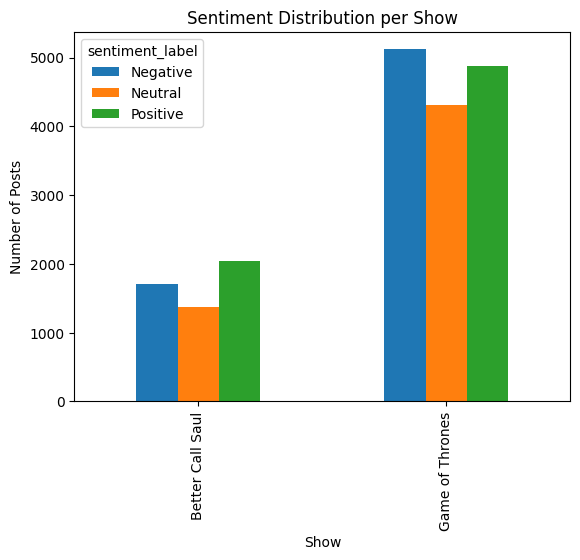

In [ ]:
# count sentiment labels
import matplotlib.pyplot as plt
# group by show and sentiment
grouped = df.groupby(["title", "sentiment_label"]).size().unstack(fill_value=0)

# plot grouped bars
grouped.plot(kind="bar")
plt.xlabel("Show")
plt.ylabel("Number of Posts")
plt.title("Sentiment Distribution per Show")
plt.show()


In [ ]:
pd.set_option('display.max_colwidth', None)
df.head(20)

,title,type,year,post,post_clean,sentiment_scores,sentiment_label
0,Better Call Saul,linear,2017,Walter. And there the chain ends.,Walter. And there the chain ends.,0.0000,Neutral
1,Better Call Saul,linear,2016,"I love this show. But it's hard to argue against its pace. It's sooooooooooo slooooowww. The writing, the acting, the direction, the production, all of it top notch. That however, doesn't mean we can't complain it's ""boring"". It's a different kind of boring, but I totally get the critique and I feel the same way. The story takes way too long to develop. It's great to have slower paced TV, but I think this show over does it. \n\nI think it'd be less of a problem if we didn't get only 10 episodes. It feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. \n\nIn the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. I think it falls short of its own potential due to just that.","I love this show. But it's hard to argue against its pace. It's sooooooooooo slooooowww. The writing, the acting, the direction, the production, all of it top notch. That however, doesn't mean we can't complain it's ""boring"". It's a different kind of boring, but I totally get the critique and I feel the same way. The story takes way too long to develop. It's great to have slower paced TV, but I think this show over does it. I think it'd be less of a problem if we didn't get only 10 episodes. It feels like you get these two and a half months a year, and then nothing, and overall nothing much happened, and that's a bit frustrating. In the end though, the show can be all those good things whilst also being possible to criticize it for how slow it is. I think it falls short of its own potential due to just that.",0.6327,Positive
2,Better Call Saul,linear,2017,What am I missing? A lot of reference to ribs on a burger.....Is this from a Carls Jr./Hardee's commercial or something?,What am I missing? A lot of reference to ribs on a burger.....Is this from a Carls Jr./Hardee's commercial or something?,-0.3736,Negative
3,Better Call Saul,linear,2018,"Oh come on Mike, he's a good little boy.","Oh come on Mike, he's a good little boy.",0.4404,Positive
4,Better Call Saul,linear,2017,Look again 👀,Look again 👀,0.0000,Neutral
5,Better Call Saul,linear,2018,"I'm watching with my mum and she was like ""Kim is kinda boring, ya know they haven't given her much to do especially so far."" Then the scene with Howard happened and she said ""Well there ya go!"".","I'm watching with my mum and she was like ""Kim is kinda boring, ya know they haven't given her much to do especially so far."" Then the scene with Howard happened and she said ""Well there ya go!"".",0.4376,Positive
6,Better Call Saul,linear,2020,"Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho.","Maybe when Jimmy gets the $7 million to ABQ, they learn that cash can't be used to bail out Lalo. Lalo then forces Jimmy to get his wife to use her good client, Mesa Verde, to launder it for him. Kim gets caught and has to disappear. Mike knows a guy, or he thinks he can find one. He implied that with Nacho.",0.2500,Positive
7,Better Call Saul,linear,2016,Didn't VG say no other BB characters would be introduced in the foreseeable future?,Didn't VG say no other BB characters would be introduced in the foreseeable future?,0.2235,Positive
8,Better Call Saul,linear,2017,"I remember spooning (gahhk that word is so bad) with my ex and falling asleep. As I slept, my face slowly slid along the pillow and my eye socket touched her hair. I felt then like I was speeding down a tunnel and that I erupted out of the tunnel into a

In [ ]:
temp = df.groupby('sentiment_label').count()['post_clean'].reset_index().sort_values(by='post_clean',ascending=False)
temp.style.background_gradient()

,sentiment_label,post_clean
2,Positive,6911
0,Negative,6825
1,Neutral,5689


In [ ]:
yearly = (
    df.groupby(['title', 'year'])
      .agg(
          n_posts=('post_clean', 'count'),
          mean_sent=('sentiment_scores', 'mean'),
          median_sent=('sentiment_scores', 'median')
      )
      .reset_index()
      .sort_values(['title', 'year'])
)

yearly

,title,year,n_posts,mean_sent,median_sent
0,Better Call Saul,2016,679,0.060639,0.0
1,Better Call Saul,2017,1938,0.031072,0.0
2,Better Call Saul,2018,1283,0.018111,0.0
3,Better Call Saul,2020,1222,0.037489,0.0
4,Game of Thrones,2015,4150,-0.031590,0.0
5,Game of Thrones,2016,5674,-0.017539,0.0
6,Game of Thrones,2017,3805,-0.021013,0.0
7,Game of Thrones,2019,674,0.007451,0.0


VADER sentiment over time

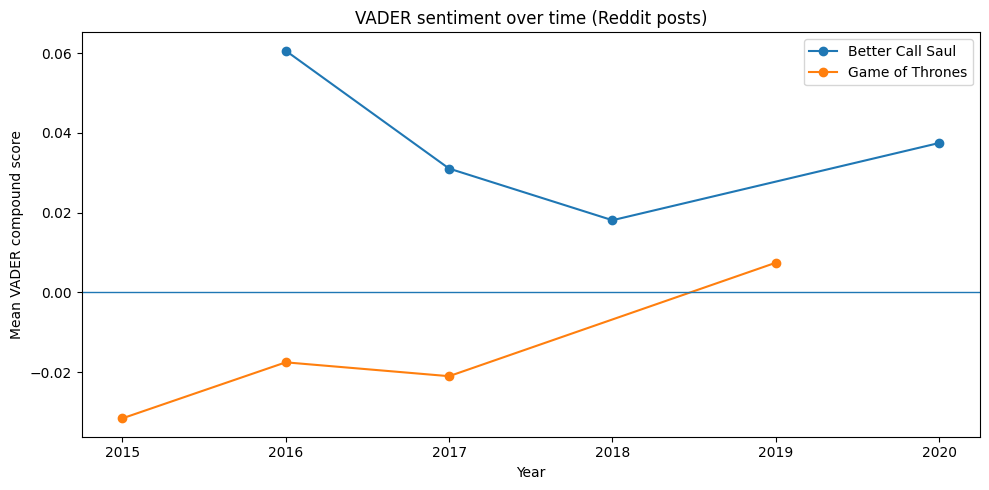

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for title in yearly['title'].unique():
    sub = yearly[yearly['title'] == title]
    plt.plot(sub['year'], sub['mean_sent'], marker='o', label=title)

plt.axhline(0, linewidth=1)
plt.xlabel("Year")
plt.ylabel("Mean VADER compound score")
plt.title("VADER sentiment over time (Reddit posts)")
plt.legend()
plt.tight_layout()
plt.show()

Number of Reddit posts per year

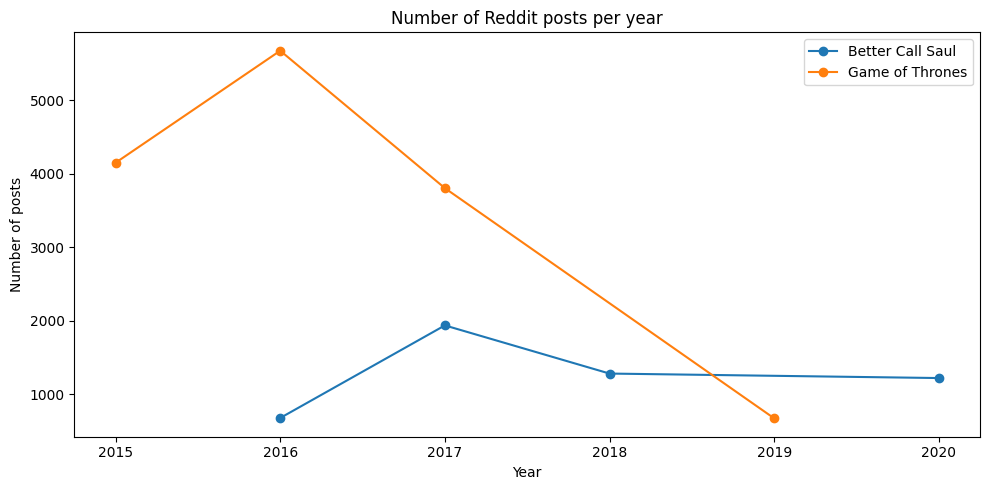

In [ ]:
plt.figure(figsize=(10,5))

for title in yearly['title'].unique():
    sub = yearly[yearly['title'] == title]
    plt.plot(sub['year'], sub['n_posts'], marker='o', label=title)

plt.xlabel("Year")
plt.ylabel("Number of posts")
plt.title("Number of Reddit posts per year")
plt.legend()
plt.tight_layout()
plt.show()

# Limitations VADER analysis

In [ ]:
penultimate = df[
    ((df['title'] == "Game of Thrones") & (df['year'] == 2017)) |
    ((df['title'] == "Better Call Saul") & (df['year'] == 2020))
]

penultimate.groupby('title').agg(
    n_posts=('post_clean', 'count'),
    mean_sent=('sentiment_scores', 'mean'),
    median_sent=('sentiment_scores', 'median')
)

,n_posts,mean_sent,median_sent
title,,,
Better Call Saul,1222,0.037489,0.0
Game of Thrones,3805,-0.021013,0.0
